In [1]:
#For data
import numpy as np
import pandas as pd

In [2]:
#For Charts
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

In [3]:
#Preprocessing
from sklearn.preprocessing import OneHotEncoder, LabelEncoder,PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import make_pipeline

In [32]:
#Regression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.svm import SVR

In [5]:
from sklearn.metrics import mean_squared_error, r2_score

In [6]:
data=pd.read_csv("/content/diamonds.csv")
data.drop('Unnamed: 0',axis=1,inplace=True)
data.head()


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [7]:
#Label Encoding
lcoder= LabelEncoder()
data['Cut_label'] = lcoder.fit_transform(data['cut'])
data['Colour_label'] = lcoder.fit_transform(data['color'])
data['Clarity_label'] = lcoder.fit_transform(data['clarity'])

In [8]:
data.head()

,carat,cut,color,clarity,depth,table,price,x,y,z,Cut_label,Colour_label,Clarity_label
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,2,1,3
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,3,1,2
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,1,1,4
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,3,5,5
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,1,6,3


In [9]:
#One Hot Encoding
data1 = data
categorical_columns = data1.select_dtypes(include=['object']).columns.tolist()
encoder = OneHotEncoder(sparse_output=False)
one_hot_encoded = encoder.fit_transform(data1[categorical_columns])
one_hot_df = pd.DataFrame(one_hot_encoded,
                          columns=encoder.get_feature_names_out(categorical_columns))

In [10]:
one_hot_df

,cut_Fair,cut_Good,cut_Ideal,cut_Premium,cut_Very Good,color_D,color_E,color_F,color_G,color_H,color_I,color_J,clarity_I1,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53935,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
53936,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
53937,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
53938,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [11]:
data

,carat,cut,color,clarity,depth,table,price,x,y,z,Cut_label,Colour_label,Clarity_label
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,2,1,3
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,3,1,2
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,1,1,4
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,3,5,5
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,1,6,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50,2,0,2
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61,1,0,2
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56,4,0,2
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74,3,4,3


In [12]:
q1 = np.quantile(data['depth'], 0.25)
q3 = np.quantile(data['depth'], 0.75)
print(q1,q3)
IQR = q3 - q1
print(IQR)
LB  = q1 - 1.5*IQR
UB  = q3 + 1.5*IQR
print(LB,UB)

61.0 62.5
1.5
58.75 64.75


In [13]:
data=data[(data["x"]<10)]
data=data[(data["y"]<30)]
data=data[(data["z"]<15)&(data["z"]>2)]
data = data[(data["depth"]<75)&(data["depth"]>50)]
data = data[(data["table"]<85)&(data["table"]>45)]
data.shape

(53899, 13)

In [14]:
X = data.drop(['cut','clarity','color','price'],axis=1)
Y = data['price']

In [15]:
X.head()

,carat,depth,table,x,y,z,Cut_label,Colour_label,Clarity_label
0,0.23,61.5,55.0,3.95,3.98,2.43,2,1,3
1,0.21,59.8,61.0,3.89,3.84,2.31,3,1,2
2,0.23,56.9,65.0,4.05,4.07,2.31,1,1,4
3,0.29,62.4,58.0,4.20,4.23,2.63,3,5,5
4,0.31,63.3,58.0,4.34,4.35,2.75,1,6,3


In [16]:
scaler_s = StandardScaler()
scaler_m = MinMaxScaler()
X_scaled_s = scaler_s.fit_transform(X)
X_scaled_m = scaler_m.fit_transform(X)

In [17]:
X_scaled_s

array([[-1.20090326, -0.17569411, -1.1041745 , ..., -0.53875955,
        -0.93687294, -0.48485396],
       [-1.24324482, -1.37295075,  1.59309901, ...,  0.43467752,
        -0.93687294, -1.06483007],
       [-1.20090326, -3.41532972,  3.39128135, ..., -1.51219662,
        -0.93687294,  0.09512215],
       ...,
       [-0.20587651,  0.73985509,  1.14355342, ...,  1.40811458,
        -1.52473211, -1.06483007],
       [ 0.13285599, -0.52782841,  0.24446225, ...,  0.43467752,
         0.82670456, -0.48485396],
       [-0.10002261,  0.31729392, -1.1041745 , ..., -0.53875955,
        -1.52473211, -0.48485396]])

In [18]:
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X_scaled_s,Y,random_state=42,test_size=0.2)

In [19]:
print(Xtrain.shape)
print(Xtest.shape)
print(Ytrain.shape)
print(Ytest.shape)

(43119, 9)
(10780, 9)
(43119,)
(10780,)


In [28]:
liner = LinearRegression()
liner_model = liner.fit(Xtrain,Ytrain)

ridge = Ridge(alpha=2.0)
ridge_model = ridge.fit(Xtrain, Ytrain)

lasso = Lasso(alpha=0.5) #0-1
lasso_model= lasso.fit(Xtrain, Ytrain)

degree = 2
poly_model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
poly_model.fit(Xtrain, Ytrain)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.218e+10, tolerance: 6.927e+07
  model = cd_fast.enet_coordinate_descent(


Pipeline(steps=[('polynomialfeatures', PolynomialFeatures()),
                ('linearregression', LinearRegression())])

In [33]:
DecisionTree = DecisionTreeRegressor()
DT_model = DecisionTree.fit(Xtrain,Ytrain)

RandomForest = RandomForestRegressor()
RF_model = RandomForest.fit(Xtrain,Ytrain)

Gradient_Boosting =  GradientBoostingRegressor()
GB_model = Gradient_Boosting.fit(Xtrain,Ytrain)

AdaBoost = AdaBoostRegressor()
AD_model = AdaBoost.fit(Xtrain,Ytrain)

SVR = SVR()
SVR_model = SVR.fit(Xtrain,Ytrain)

KNN = KNeighborsRegressor()
Knn_model = KNN.fit(Xtrain,Ytrain)

In [26]:
def result(model):
  Y_pre = model.predict(Xtest)
  mse = mean_squared_error(Ytest,Y_pre)
  r2 = r2_score(Ytest, Y_pre)
  return mse,r2

In [ ]:
Y_pre = liner_model.predict(Xtest)

In [ ]:
Y_pre

array([3130.46220318, 1273.30658198, 1038.05314897, ..., 3404.96864311,
       1127.76659726, 4379.82361831])

In [ ]:
mse = mean_squared_error(Ytest,Y_pre)
r2 = r2_score(Ytest, Y_pre)

In [ ]:
print(mse)
print(r2)

1711820.2970055572
0.8869281488454701


In [ ]:
#Xtest.to_csv("Xtest.csv",index=False)

In [ ]:
#Xtest['Y_pre'] = Y_pre
#Xtest['Y_test'] = Ytest
#Xtest.to_csv("Xtest.csv",index=False)

In [34]:
models = [liner_model, ridge_model, lasso_model, poly_model, DT_model, RF_model, GB_model,
          AD_model, SVR_model, Knn_model]
for i in models:
  mse, r2 = result(i)
  print("\tmodel: ",i)
  print("MSE: ",mse)
  print("R2: ",r2)

	model:  LinearRegression()
MSE:  1711820.2970055572
R2:  0.8869281488454701
	model:  Ridge(alpha=2.0)
MSE:  1711783.37218644
R2:  0.8869305878617958
	model:  Lasso(alpha=0.5)
MSE:  1713310.129249099
R2:  0.8868297400989552
	model:  Pipeline(steps=[('polynomialfeatures', PolynomialFeatures()),
                ('linearregression', LinearRegression())])
MSE:  992528.2221174046
R2:  0.9344399621886449
	model:  DecisionTreeRegressor()
MSE:  527313.7241883117
R2:  0.9651690431306015
	model:  RandomForestRegressor()
MSE:  291700.2830248552
R2:  0.9807321533448241
	model:  GradientBoostingRegressor()
MSE:  424717.0680809407
R2:  0.9719459190962727
	model:  AdaBoostRegressor()
MSE:  1874835.1475246907
R2:  0.8761604351163358
	model:  SVR()
MSE:  7147334.45107752
R2:  0.5278930045299857
	model:  KNeighborsRegressor()
MSE:  631363.4511502782
R2:  0.9582961866395939


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [ ]:
data=pd.read_csv("/content/diabetes.csv")
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
X = data.drop(['Outcome'],axis=1)
Y = data['Outcome']

In [ ]:
Xtrain, Xtest, Ytrian, Ytest = train_test_split(X,Y,random_state=42,test_size=0.2)

In [ ]:
Logistic_Regression = LogisticRegression()
LR_model = Logistic_Regression.fit(Xtrain,Ytrian)

Decision_Tree = DecisionTreeClassifier()
DT_model = Decision_Tree.fit(Xtrain,Ytrian)

Random_Forest = RandomForestClassifier()
RF_model = Random_Forest.fit(Xtrain,Ytrian)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:

Gradient_Boosting = GradientBoostingClassifier()
GB_model = Gradient_Boosting.fit(Xtrain,Ytrian)

AdaBoost = AdaBoostClassifier()
AD_model = AdaBoost.fit(Xtrain,Ytrian)

SVM = SVC()
SVM_model = SVM.fit(Xtrain,Ytrian)

KNN = KNeighborsClassifier()
Knn_model = KNN.fit(Xtrain,Ytrian)

Naive_Bayes = GaussianNB()
NB_model = Naive_Bayes.fit(Xtrain,Ytrian)

In [ ]:
XGBoost = XGBClassifier()
XGB_model = XGBoost.fit(Xtrain,Ytrian)

In [ ]:
def result(model):
  y_pre = model.predict(Xtest)
  acc = accuracy_score(Ytest, y_pre)
  prec = precision_score(Ytest, y_pre)
  rec = recall_score(Ytest, y_pre)
  f1 = f1_score(Ytest, y_pre)
  return acc, prec, rec, f1

In [ ]:
Xtest.shape

(154, 8)

In [ ]:
y_pre = LR_model.predict(Xtest)


In [ ]:
Xtest['y_pre1'] = y_pre
Xtest['y_test1'] = Ytest
Xtest.to_csv("Xtest.csv",index=False)

In [ ]:
models = [LR_model, DT_model, RF_model, GB_model]#, 'AD_model', 'SVM_model', 'Knn_model', 'NB_model', 'XGB_model']
for model in models:
  acc, prec, rec, f1 = result(model)
  print("\tmodel: ",model)
  print("Accuracy: ",acc)
  print("Precision: ",prec)
  print("Recall: ",rec)
  print("F1: ",f1)

	model:  LogisticRegression()
Accuracy:  0.7402597402597403
Precision:  0.631578947368421
Recall:  0.6545454545454545
F1:  0.6428571428571429
	model:  DecisionTreeClassifier()
Accuracy:  0.7402597402597403
Precision:  0.6229508196721312
Recall:  0.6909090909090909
F1:  0.6551724137931034
	model:  RandomForestClassifier()
Accuracy:  0.7402597402597403
Precision:  0.6363636363636364
Recall:  0.6363636363636364
F1:  0.6363636363636364
	model:  GradientBoostingClassifier()
Accuracy:  0.7467532467532467
Precision:  0.6379310344827587
Recall:  0.6727272727272727
F1:  0.6548672566371682


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

In [ ]:
# 1. Load the dataset
df = pd.read_csv('/content/corrected_marketing_campaign (1).csv')  # Replace with your actual file path

# 2. Basic preprocessing
df = df.copy()
df['Age'] = 2025 - df['Year_Birth']
df['TotalChildren'] = df['Kidhome'] + df['Teenhome']
df['TotalSpent'] = df[['MntWines', 'MntFruits', 'MntMeatProducts',
                       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum(axis=1)

In [ ]:
df_cluster = df[['Income', 'Age', 'TotalChildren', 'Recency', 'TotalSpent']].dropna()

# 3. Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

In [ ]:
inertia = []
sil_scores = []
K = range(2, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot elbow + silhouette
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(K, inertia, 'bo-')
plt.title('K-Means Elbow Curve')
plt.xlabel('k'), plt.ylabel('Inertia')

plt.subplot(1, 2, 2)
plt.plot(K, sil_scores, 'go-')
plt.title('Silhouette Score')
plt.xlabel('k'), plt.ylabel('Score')
#plt.tight_layout()
plt.show()



NameError: name 'X_scaled' is not defined

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)
df_cluster['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

In [ ]:
df_cluster

,Income,Age,TotalChildren,Recency,TotalSpent,KMeans_Cluster
0,58138.0,68,0,58,1617,2
1,46344.0,71,2,38,27,3
2,71613.0,60,0,26,776,2
3,26646.0,41,1,26,53,0
4,58293.0,44,1,94,422,0
...,...,...,...,...,...,...
2235,61223.0,58,1,46,1341,1
2236,64014.0,79,3,56,444,3
2237,56981.0,44,0,91,1241,1
2238,69245.0,69,1,8,843,2


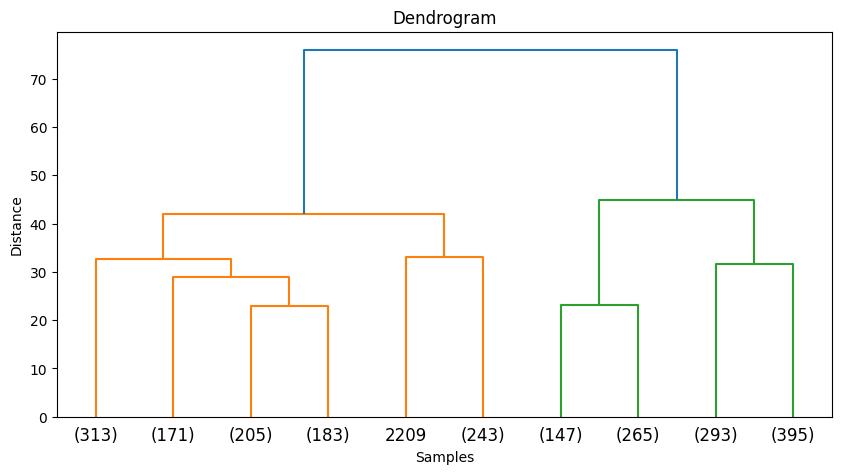

In [ ]:
# ================================
# 5. HIERARCHICAL CLUSTERING
# ================================
# Linkage and dendrogram
linked = linkage(X_scaled, method='ward')
plt.figure(figsize=(10, 5))
dendrogram(linked, truncate_mode='lastp', p=10)
plt.title("Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()


In [ ]:
# Assign clusters
df_cluster['Hierarchical_Cluster'] = fcluster(linked, t=4, criterion='maxclust')

In [ ]:
df_cluster

,Income,Age,TotalChildren,Recency,TotalSpent,KMeans_Cluster,Hierarchical_Cluster
0,58138.0,68,0,58,1617,2,1
1,46344.0,71,2,38,27,3,3
2,71613.0,60,0,26,776,2,1
3,26646.0,41,1,26,53,0,4
4,58293.0,44,1,94,422,0,4
...,...,...,...,...,...,...,...
2235,61223.0,58,1,46,1341,1,1
2236,64014.0,79,3,56,444,3,3
2237,56981.0,44,0,91,1241,1,2
2238,69245.0,69,1,8,843,2,1


In [ ]:
# ================================
# 6. DBSCAN CLUSTERING
# ================================
db = DBSCAN(eps=1, min_samples=5)
df_cluster['DBSCAN_Cluster'] = db.fit_predict(X_scaled)


In [ ]:
df_cluster

,Income,Age,TotalChildren,Recency,TotalSpent,KMeans_Cluster,Hierarchical_Cluster,DBSCAN_Cluster
0,58138.0,68,0,58,1617,2,1,0
1,46344.0,71,2,38,27,3,3,1
2,71613.0,60,0,26,776,2,1,0
3,26646.0,41,1,26,53,0,4,2
4,58293.0,44,1,94,422,0,4,2
...,...,...,...,...,...,...,...,...
2235,61223.0,58,1,46,1341,1,1,2
2236,64014.0,79,3,56,444,3,3,-1
2237,56981.0,44,0,91,1241,1,2,0
2238,69245.0,69,1,8,843,2,1,2


In [ ]:
# Optional: Compare clusters
print(df_cluster[['KMeans_Cluster', 'Hierarchical_Cluster', 'DBSCAN_Cluster']].value_counts())

KMeans_Cluster  Hierarchical_Cluster  DBSCAN_Cluster
0               4                      2                566
3               3                      1                365
2               1                      2                347
1               2                      0                234
2               1                      0                170
1               1                      2                134
                                       0                104
0               4                      0                 96
                1                      2                 45
3               3                      3                 40
                1                      1                 36
2               4                      2                 17
0               1                      0                 13
1               2                     -1                  7
2               1                      1                  7
                4                      0       

In [ ]:
###PCA
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_digits

In [ ]:
datasets = load_digits()
datasets.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

<Figure size 640x480 with 0 Axes>

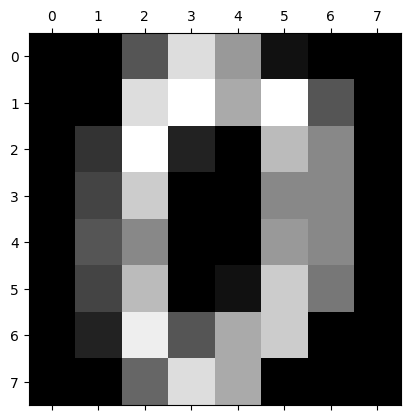

In [ ]:
from matplotlib import pyplot as plt
%matplotlib inline

plt.gray()
plt.matshow(datasets.images[0])
plt.show()

In [ ]:
datasets.target[0]

np.int64(0)

In [ ]:
df = pd.DataFrame(datasets.data,columns=datasets.feature_names)
df.head()

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,pixel_1_2,pixel_1_3,pixel_1_4,pixel_1_5,pixel_1_6,pixel_1_7,pixel_2_0,pixel_2_1,pixel_2_2,pixel_2_3,pixel_2_4,pixel_2_5,pixel_2_6,pixel_2_7,pixel_3_0,pixel_3_1,pixel_3_2,pixel_3_3,pixel_3_4,pixel_3_5,pixel_3_6,pixel_3_7,pixel_4_0,pixel_4_1,pixel_4_2,pixel_4_3,pixel_4_4,pixel_4_5,pixel_4_6,pixel_4_7,pixel_5_0,pixel_5_1,pixel_5_2,pixel_5_3,pixel_5_4,pixel_5_5,pixel_5_6,pixel_5_7,pixel_6_0,pixel_6_1,pixel_6_2,pixel_6_3,pixel_6_4,pixel_6_5,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,13.0,15.0,10.0,15.0,5.0,0.0,0.0,3.0,15.0,2.0,0.0,11.0,8.0,0.0,0.0,4.0,12.0,0.0,0.0,8.0,8.0,0.0,0.0,5.0,8.0,0.0,0.0,9.0,8.0,0.0,0.0,4.0,11.0,0.0,1.0,12.0,7.0,0.0,0.0,2.0,14.0,5.0,10.0,12.0,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,0.0,11.0,16.0,9.0,0.0,0.0,0.0,0.0,3.0,15.0,16.0,6.0,0.0,0.0,0.0,7.0,15.0,16.0,16.0,2.0,0.0,0.0,0.0,0.0,1.0,16.0,16.0,3.0,0.0,0.0,0.0,0.0,1.0,16.0,16.0,6.0,0.0,0.0,0.0,0.0,1.0,16.0,16.0,6.0,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,3.0,16.0,15.0,14.0,0.0,0.0,0.0,0.0,8.0,13.0,8.0,16.0,0.0,0.0,0.0,0.0,1.0,6.0,15.0,11.0,0.0,0.0,0.0,1.0,8.0,13.0,15.0,1.0,0.0,0.0,0.0,9.0,16.0,16.0,5.0,0.0,0.0,0.0,0.0,3.0,13.0,16.0,16.0,11.0,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,13.0,6.0,15.0,4.0,0.0,0.0,0.0,2.0,1.0,13.0,13.0,0.0,0.0,0.0,0.0,0.0,2.0,15.0,11.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,12.0,12.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,10.0,8.0,0.0,0.0,0.0,8.0,4.0,5.0,14.0,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,8.0,0.0,0.0,0.0,0.0,0.0,1.0,13.0,6.0,2.0,2.0,0.0,0.0,0.0,7.0,15.0,0.0,9.0,8.0,0.0,0.0,5.0,16.0,10.0,0.0,16.0,6.0,0.0,0.0,4.0,15.0,16.0,13.0,16.0,1.0,0.0,0.0,0.0,0.0,3.0,15.0,10.0,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


In [ ]:
X = df
Y = datasets.target

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.decomposition import PCA
#pca = PCA(n_components=2)
pca = PCA(0.70)
X_pca = pca.fit_transform(X_scaled)
X_pca.shape

(1797, 15)

In [ ]:
pca.explained_variance_ratio_

array([0.12033916, 0.09561054, 0.08444415, 0.06498408, 0.04860155,
       0.0421412 , 0.03942083, 0.03389381, 0.02998221, 0.02932003,
       0.02781805, 0.02577055, 0.02275303, 0.0222718 , 0.02165229])

In [ ]:
#LDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.datasets import load_wine

In [ ]:
X = datasets.data
Y = datasets.target
X.shape

(1797, 64)

In [ ]:
X_scaled = scaler.fit_transform(X)
LDA = LinearDiscriminantAnalysis(n_components=2)
X_LDA = LDA.fit_transform(X_scaled,Y)

In [ ]:
LDA.explained_variance_ratio_

array([0.28912041, 0.18262788])

In [ ]:
!pip install surprise

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 3.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp311-cp311-linux_x86_64.whl size=2463305 sha256=96e24e13578910b7b7bf9344b1cd52cf0f95a40f71c4c8df09ead4c959f95b91
  Stored in directory: /root/.cache/pip/wheels/2a/8f/6e/7e2899163e2d85d8266daab4aa1cdabec7a6c56f83c015b5af
Successfully built scikit-surprise


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import pairwise_distances
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
import warnings
from sklearn.metrics.pairwise import cosine_similarity
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("book.csv", encoding = "ISO-8859-1", index_col = 0)
df.columns=["User_ID","Book_Title","Book_Rating"]
df

,User_ID,Book_Title,Book_Rating
1,276726,Classical Mythology,5
2,276729,Clara Callan,3
3,276729,Decision in Normandy,6
4,276736,Flu: The Story of the Great Influenza Pandemic...,8
5,276737,The Mummies of Urumchi,6
...,...,...,...
9996,162121,American Fried: Adventures of a Happy Eater.,7
9997,162121,Cannibal In Manhattan,9
9998,162121,How to Flirt: A Practical Guide,7
9999,162121,Twilight,8


In [ ]:
for i in df.columns:
    print("The dataset has", len(df[i].unique()), "Unique", i)

The dataset has 2182 Unique User_ID
The dataset has 9659 Unique Book_Title
The dataset has 10 Unique Book_Rating


In [ ]:
df["Book_Rating"].value_counts()

,count
Book_Rating,
8,2283
7,2076
10,1732
9,1493
5,1007
6,920
4,237
3,146
2,63


In [ ]:
ratings_matrix = df.pivot_table(index='User_ID', columns='Book_Title', values='Book_Rating').fillna(0)
ratings_matrix

Book_Title,"Jason, Madison &amp",Other Stories;Merril;1985;McClelland &amp,Repairing PC Drives &amp,'48,'O Au No Keia: Voices from Hawai'I's Mahu and Transgender Communities,...AND THE HORSE HE RODE IN ON : THE PEOPLE V. KENNETH STARR,01-01-00: A Novel of the Millennium,"1,401 More Things That P*Ss Me Off",10 Commandments Of Dating,"100 Great Fantasy Short, Short Stories",...,Zora Hurston and the Chinaberry Tree (Reading Rainbow Book),\Even Monkeys Fall from Trees\ and Other Japanese Proverbs,\I Won't Learn from You\: And Other Thoughts on Creative Maladjustment,"\More More More,\ Said the Baby",\O\ Is for Outlaw,"\Surely You're Joking, Mr. Feynman!\: Adventures of a Curious Character","\Well, there's your problem\: Cartoons",iI Paradiso Degli Orchi,stardust,Ã?Â?bermorgen.
User_ID,,,,,,,,,,,,,,,,,,,,,
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278846,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
278849,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
278851,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,0.0,0.0


In [ ]:
def popularity_recommender(df, top_n=10):
    popular_books = df.groupby('Book_Title')['Book_Rating'].mean().sort_values(ascending=False).head(top_n)
    return popular_books

print("\nPopular Books:\n", popularity_recommender(df))


Popular Books:
 Book_Title
1001 Brilliant Ways to Checkmate                     10.0
Zeit im Wind.                                        10.0
1,401 More Things That P*Ss Me Off                   10.0
Z for Zachariah                                      10.0
Guidepost Treasury of Love                           10.0
Guilt                                                10.0
She Who Remembers                                    10.0
She's Come Undone (Oprah's Book Club (Paperback))    10.0
Shallows of Night                                    10.0
Hand Of An Angel (Silhouette Desire, No 844)         10.0
Name: Book_Rating, dtype: float64


In [ ]:
book_user_matrix = ratings_matrix.T  # transpose for item-based
cos_sim = cosine_similarity(book_user_matrix)
cos_sim_df = pd.DataFrame(cos_sim, index=book_user_matrix.index, columns=book_user_matrix.index)

In [ ]:
cos_sim_df

Book_Title,"Jason, Madison &amp",Other Stories;Merril;1985;McClelland &amp,Repairing PC Drives &amp,'48,'O Au No Keia: Voices from Hawai'I's Mahu and Transgender Communities,...AND THE HORSE HE RODE IN ON : THE PEOPLE V. KENNETH STARR,01-01-00: A Novel of the Millennium,"1,401 More Things That P*Ss Me Off",10 Commandments Of Dating,"100 Great Fantasy Short, Short Stories",...,Zora Hurston and the Chinaberry Tree (Reading Rainbow Book),\Even Monkeys Fall from Trees\ and Other Japanese Proverbs,\I Won't Learn from You\: And Other Thoughts on Creative Maladjustment,"\More More More,\ Said the Baby",\O\ Is for Outlaw,"\Surely You're Joking, Mr. Feynman!\: Adventures of a Curious Character","\Well, there's your problem\: Cartoons",iI Paradiso Degli Orchi,stardust,Ã?Â?bermorgen.
Book_Title,,,,,,,,,,,,,,,,,,,,,
"Jason, Madison &amp",1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Other Stories;Merril;1985;McClelland &amp,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Repairing PC Drives &amp,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
'48,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
'O Au No Keia: Voices from Hawai'I's Mahu and Transgender Communities,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"\Surely You're Joking, Mr. Feynman!\: Adventures of a Curious Character",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
"\Well, there's your problem\: Cartoons",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
iI Paradiso Degli Orchi,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
def item_based_recommender(book_name, top_n=6):
    if book_name in cos_sim_df:
        return cos_sim_df[book_name].sort_values(ascending=False)[1:top_n+1]
    else:
        return "Book not in dataset"

print("\nItem-based recommendations for ' Jason, Madison &amp':\n", item_based_recommender(' Jason, Madison &amp'))



Item-based recommendations for ' Jason, Madison &amp':
 Book_Title
 Other Stories;Merril;1985;McClelland &amp        1.0
 Jason, Madison &amp                              1.0
 Repairing PC Drives &amp                         1.0
Dictionary of Geography (Reference Books)         1.0
Spot Visits His Grandparents (Picture Puffins)    0.0
Name:  Jason, Madison &amp, dtype: float64


In [ ]:
# Step 6: Collaborative Filtering (User-Based with k-NN)
model_knn = NearestNeighbors(metric='cosine', algorithm='brute')
model_knn.fit(ratings_matrix)

NearestNeighbors(algorithm='brute', metric='cosine')

In [ ]:
def user_based_recommender(user_id, n_neighbors=3):
    if user_id in ratings_matrix.index:
        distances, indices = model_knn.kneighbors([ratings_matrix.loc[user_id]], n_neighbors=n_neighbors+1)
        similar_users = ratings_matrix.index[indices.flatten()[1:]]
        return similar_users
    else:
        return "User not in dataset"

print("\nSimilar users to User 276772:\n", user_based_recommender(276772))


Similar users to User 276772:
 Index([278843, 278836, 278832], dtype='int64', name='User_ID')
